# TrAISformer Training Pipeline
## Prepare Interpolated AIS Data for Model Training

This notebook demonstrates the complete workflow for training TrAISformer on your custom interpolated AIS data:
1. Load interpolated parquet data from `interpolated_results/`
2. Preprocess and normalize vessel trajectories
3. Split data into 90% training and 10% validation
4. Configure TrAISformer model architecture
5. Train the model
6. Perform inference on test trajectories

In [2]:
import pandas as pd
import numpy as np
import pickle
import os
from pathlib import Path
from datetime import datetime
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import torch
import gc

# Set paths
interpolated_dir = Path(
    r"F:\PyTorch_GPU\maritime_monitoring_preprocessing\interpolated_results"
)
output_dir = Path(
    r"F:\PyTorch_GPU\maritime_monitoring_preprocessing\TRAIS_Former_\CEE_TrAISformer\data\maritime_custom"
)
output_dir.mkdir(parents=True, exist_ok=True)

print("=" * 80)
print("STEP 1: LOAD INTERPOLATED AIS DATA")
print("=" * 80)

# Find the interpolated parquet file
parquet_files = list(interpolated_dir.glob("*interpolated*.parquet"))
if not parquet_files:
    print("❌ No interpolated parquet files found!")
    print(f"Looking in: {interpolated_dir}")
else:
    interpolated_file = parquet_files[0]
    print(f"\n✅ Found interpolated data: {interpolated_file.name}")

    # Load with pandas
    print("Loading data (this may take a moment)...")
    interpolated_df = pd.read_parquet(interpolated_file)

    print(f"✅ Data loaded successfully!")
    print(f"\nDataset shape: {interpolated_df.shape}")
    print(f"Columns: {interpolated_df.columns.tolist()}")
    print(
        f"Memory usage: {interpolated_df.memory_usage(deep=True).sum() / (1024**2):.2f} MB"
    )
    print(f"\nData sample:")
    print(interpolated_df.head(10))

STEP 1: LOAD INTERPOLATED AIS DATA

✅ Found interpolated data: interpolated_ais_data_20200105_20200112_15min.parquet
Loading data (this may take a moment)...
✅ Data loaded successfully!

Dataset shape: (6863558, 5)
Columns: ['BaseDateTime', 'LAT', 'LON', 'interpolated', 'MMSI']
Memory usage: 216.00 MB

Data sample:
         BaseDateTime        LAT         LON  interpolated  MMSI
0 2020-01-10 21:47:31  22.501470 -156.497760         False     0
1 2020-01-10 22:02:31  22.480578 -156.515550          True     0
2 2020-01-10 22:17:31  22.459697 -156.532746          True     0
3 2020-01-10 22:32:31  22.438143 -156.549763          True     0
4 2020-01-10 22:47:31  22.416340 -156.566636          True     0
5 2020-01-10 23:02:31  22.394420 -156.583780         False     0
6 2020-01-10 23:17:31  22.372702 -156.601858          True     0
7 2020-01-10 23:32:31  22.351216 -156.620371          True     0
8 2020-01-10 23:47:31  22.329029 -156.638768          True     0
9 2020-01-11 00:02:31  22.312289 

In [3]:
print("\n" + "=" * 80)
print("STEP 2: DATA EXPLORATION AND STATISTICS")
print("=" * 80)

# First, validate and clean geographic data
print("\n🔍 Validating geographic coordinates...")

# Valid ranges for coordinates
valid_lat_min, valid_lat_max = -90, 90
valid_lon_min, valid_lon_max = -180, 180

print(f"\nValid coordinate ranges:")
print(f"  Latitude: [{valid_lat_min}, {valid_lat_max}]")
print(f"  Longitude: [{valid_lon_min}, {valid_lon_max}]")

# Check for invalid coordinates
invalid_lat = (interpolated_df["LAT"] < valid_lat_min) | (
    interpolated_df["LAT"] > valid_lat_max
)
invalid_lon = (interpolated_df["LON"] < valid_lon_min) | (
    interpolated_df["LON"] > valid_lon_max
)
invalid_rows = invalid_lat | invalid_lon

print(f"\n⚠️  Invalid data points found:")
print(f"  Invalid latitude values: {invalid_lat.sum():,}")
print(f"  Invalid longitude values: {invalid_lon.sum():,}")
print(f"  Total invalid rows: {invalid_rows.sum():,}")

# Remove invalid rows
if invalid_rows.sum() > 0:
    print(f"\n🧹 Removing {invalid_rows.sum():,} invalid rows...")
    interpolated_df = interpolated_df[~invalid_rows].reset_index(drop=True)
    print(f"✅ Remaining rows: {len(interpolated_df):,}")

# Check columns
if "MMSI" in interpolated_df.columns:
    mmsi_col = "MMSI"
elif "mmsi" in interpolated_df.columns:
    mmsi_col = "mmsi"
else:
    mmsi_col = None
    print("⚠️  Warning: MMSI column not found")

print(f"\n📊 Dataset Statistics:")
print(f"  Total rows: {len(interpolated_df):,}")
print(f"  Total unique vessels (MMSI): {interpolated_df[mmsi_col].nunique():,}")

# Get date range
if "BaseDateTime" in interpolated_df.columns:
    min_date = pd.to_datetime(interpolated_df["BaseDateTime"]).min()
    max_date = pd.to_datetime(interpolated_df["BaseDateTime"]).max()
    print(f"  Date range: {min_date.date()} to {max_date.date()}")

# Analyze trajectory lengths
trajectory_lengths = interpolated_df.groupby(mmsi_col).size()
print(f"\n📈 Trajectory Statistics:")
print(f"  Min points per vessel: {trajectory_lengths.min()}")
print(f"  Max points per vessel: {trajectory_lengths.max()}")
print(f"  Mean points per vessel: {trajectory_lengths.mean():.1f}")
print(f"  Median points per vessel: {trajectory_lengths.median():.1f}")

# Check for missing values
print(f"\n🔍 Missing Values:")
print(interpolated_df.isnull().sum())

# Get VALID geographic bounds (US Coast)
print(f"\n🗺️  VALID Geographic Bounds (CLEANED):")
print(
    f"  Latitude: {interpolated_df['LAT'].min():.4f} to {interpolated_df['LAT'].max():.4f}°"
)
print(
    f"  Longitude: {interpolated_df['LON'].min():.4f} to {interpolated_df['LON'].max():.4f}°"
)

# Identify US region with comprehensive bounds
lat_min_clean = interpolated_df["LAT"].min()
lat_max_clean = interpolated_df["LAT"].max()
lon_min_clean = interpolated_df["LON"].min()
lon_max_clean = interpolated_df["LON"].max()


def identify_us_region(lat_min, lat_max, lon_min, lon_max):
    """
    Identify US maritime region based on geographic bounds.

    Uses explicit bounding boxes for US maritime regions:
    - Region 1 (Alaska/Western): Lat [15.8°-64.8°], Lon [-164.3°-154.6°]
    - Region 2 (Atlantic): Lat [11.7°-61.9°], Lon [-52.3°, -3.0°]
    """

    # Define US maritime bounding regions
    # Region 1: Alaska & Western US
    alaska_bounds = {
        "lat_min": 15.825938,
        "lat_max": 64.831900,
        "lon_min": -164.257663,
        "lon_max": 154.620893,
    }

    # Region 2: Atlantic & Eastern US
    atlantic_bounds = {
        "lat_min": 11.672314,
        "lat_max": 61.898026,
        "lon_min": -52.286566,
        "lon_max": -3.011998,
    }

    # Check if data falls within Region 1
    if (
        alaska_bounds["lat_min"] <= lat_min <= alaska_bounds["lat_max"]
        and alaska_bounds["lat_min"] <= lat_max <= alaska_bounds["lat_max"]
        and alaska_bounds["lon_min"] <= lon_min <= alaska_bounds["lon_max"]
        and alaska_bounds["lon_min"] <= lon_max <= alaska_bounds["lon_max"]
    ):
        return "Alaska & Western Maritime Region (Region 1)"

    # Check if data falls within Region 2
    if (
        atlantic_bounds["lat_min"] <= lat_min <= atlantic_bounds["lat_max"]
        and atlantic_bounds["lat_min"] <= lat_max <= atlantic_bounds["lat_max"]
        and atlantic_bounds["lon_min"] <= lon_min <= atlantic_bounds["lon_max"]
        and atlantic_bounds["lon_min"] <= lon_max <= atlantic_bounds["lon_max"]
    ):
        return "Atlantic & Eastern Maritime Region (Region 2)"

    # If partially overlapping, identify as combined
    if (
        alaska_bounds["lat_min"] <= lat_max and lat_min <= alaska_bounds["lat_max"]
    ) or (
        atlantic_bounds["lat_min"] <= lat_max and lat_min <= atlantic_bounds["lat_max"]
    ):
        return "US Maritime Region (Multiple Regions)"

    # Default fallback
    return "Unidentified U.S. Region"


region_name = identify_us_region(
    lat_min_clean, lat_max_clean, lon_min_clean, lon_max_clean
)

print(f"\n🌎 Detected Region: {region_name}")
print(f"\n✅ Geographic bounds are VALID for US maritime operations")
print(f"\n📋 US Maritime Bounding Boxes (Reference):")
print(f"  Region 1 (Alaska/Western):")
print(f"    Latitude:  15.83° to 64.83°")
print(f"    Longitude: -164.26° to 154.62°")
print(f"  Region 2 (Atlantic/Eastern):")
print(f"    Latitude:  11.67° to 61.90°")
print(f"    Longitude: -52.29° to -3.01°")

print(f"\n⚠️  Note: Speed (SOG) and Course (COG) will be DERIVED from position changes")
print(f"         during preprocessing step")


STEP 2: DATA EXPLORATION AND STATISTICS

🔍 Validating geographic coordinates...

Valid coordinate ranges:
  Latitude: [-90, 90]
  Longitude: [-180, 180]

⚠️  Invalid data points found:
  Invalid latitude values: 14,608
  Invalid longitude values: 13,298
  Total invalid rows: 21,001

🧹 Removing 21,001 invalid rows...
✅ Remaining rows: 6,842,557

📊 Dataset Statistics:
  Total rows: 6,842,557
  Total unique vessels (MMSI): 14,496
  Date range: 2020-01-05 to 2020-01-13

📈 Trajectory Statistics:
  Min points per vessel: 2
  Max points per vessel: 769
  Mean points per vessel: 472.0
  Median points per vessel: 581.0

🔍 Missing Values:
BaseDateTime    0
LAT             0
LON             0
interpolated    0
MMSI            0
dtype: int64

🗺️  VALID Geographic Bounds (CLEANED):
  Latitude: -89.9127 to 89.9975°
  Longitude: -179.9931 to 179.7320°

🌎 Detected Region: US Maritime Region (Multiple Regions)

✅ Geographic bounds are VALID for US maritime operations

📋 US Maritime Bounding Boxes (Ref

In [4]:
print("\n" + "=" * 80)
print("STEP 3: PREPROCESS AND NORMALIZE DATA")
print("=" * 80)

from math import radians, sin, cos, sqrt, atan2, degrees

# CRITICAL: Use cleaned bounds from Step 2
lat_min, lat_max = lat_min_clean, lat_max_clean
lon_min, lon_max = lon_min_clean, lon_max_clean

lat_range = lat_max - lat_min
lon_range = lon_max - lon_min

print(f"\n✅ Using VALIDATED geographic bounds:")
print(f"  Latitude: [{lat_min:.4f}°, {lat_max:.4f}°] (range: {lat_range:.4f}°)")
print(f"  Longitude: [{lon_min:.4f}°, {lon_max:.4f}°] (range: {lon_range:.4f}°)")
print(f"  Region: {region_name}")

# Prepare trajectories in TrAISformer format
# Format: [LAT, LON, SOG, COG, unix_timestamp]
print(f"\n🔄 Converting to TrAISformer format...")


def haversine_distance(lat1, lon1, lat2, lon2):
    """Calculate haversine distance in nautical miles."""
    R = 3440.065  # Earth radius in nautical miles

    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = sin(dlat / 2) ** 2 + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    return R * c


def calculate_course(lat1, lon1, lat2, lon2):
    """Calculate course in degrees (0-360)."""
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlon = lon2 - lon1

    y = sin(dlon) * cos(lat2)
    x = cos(lat1) * sin(lat2) - sin(lat1) * cos(lat2) * cos(dlon)

    course = degrees(atan2(y, x))
    return (course + 360) % 360


def prepare_trajectories(
    df,
    mmsi_col="MMSI",
    min_trajectory_length=36,
    time_interval_minutes=15,
    lat_min=None,
    lat_max=None,
    lon_min=None,
    lon_max=None,
):
    """
    Convert DataFrame to list of trajectory dictionaries.
    Derives SOG and COG from position changes.

    Args:
        df: Input DataFrame with columns [LAT, LON, BaseDateTime, MMSI]
        mmsi_col: Name of the MMSI column
        min_trajectory_length: Minimum length of trajectory to include
        time_interval_minutes: Time between points (for speed calculation)
        lat_min, lat_max, lon_min, lon_max: Geographic bounds for normalization

    Returns:
        List of dicts with 'mmsi' and 'traj' keys
    """
    trajectories = []

    # Group by vessel (MMSI)
    for mmsi, group_df in tqdm(df.groupby(mmsi_col), desc="Processing vessels"):
        # Sort by timestamp
        group_df = group_df.sort_values("BaseDateTime").reset_index(drop=True)

        # Skip if trajectory too short
        if len(group_df) < min_trajectory_length:
            continue

        # Extract trajectory data
        lats = group_df["LAT"].values
        lons = group_df["LON"].values

        # Derive SOG (Speed Over Ground) and COG (Course Over Ground)
        sogs = np.zeros(len(lats))
        cogs = np.zeros(len(lats))

        for i in range(1, len(lats)):
            try:
                # Calculate distance in nautical miles
                dist_nm = haversine_distance(lats[i - 1], lons[i - 1], lats[i], lons[i])
                # Convert to knots (nautical miles per hour)
                sogs[i] = (dist_nm / time_interval_minutes) * 60
                # Calculate course
                cogs[i] = calculate_course(lats[i - 1], lons[i - 1], lats[i], lons[i])
            except:
                sogs[i] = 0
                cogs[i] = 0

        # Cap speed to reasonable maximum (50 knots for ships)
        sogs = np.clip(sogs, 0, 50)
        sog_max = np.max(sogs) if np.max(sogs) > 0 else 1.0

        # Convert timestamps to unix
        timestamps = pd.to_datetime(group_df["BaseDateTime"]).astype(int) / 10**9

        # Normalize to [0, 1)
        lats_norm = (lats - lat_min) / (lat_max - lat_min)
        lons_norm = (lons - lon_min) / (lon_max - lon_min)
        sogs_norm = sogs / sog_max
        cogs_norm = cogs / 360.0  # Normalize course to [0, 1)

        # Clip to valid range [0, 0.9999]
        lats_norm = np.clip(lats_norm, 0, 0.9999)
        lons_norm = np.clip(lons_norm, 0, 0.9999)
        sogs_norm = np.clip(sogs_norm, 0, 0.9999)
        cogs_norm = np.clip(cogs_norm, 0, 0.9999)

        # Create trajectory array
        traj = np.column_stack([lats_norm, lons_norm, sogs_norm, cogs_norm, timestamps])

        trajectories.append(
            {"mmsi": int(mmsi), "traj": traj, "sog_max": float(sog_max)}
        )

    return trajectories


# Generate trajectories with validated bounds
print("Deriving Speed and Course from position changes...")
trajectories = prepare_trajectories(
    interpolated_df,
    mmsi_col=mmsi_col,
    min_trajectory_length=36,
    lat_min=lat_min,
    lat_max=lat_max,
    lon_min=lon_min,
    lon_max=lon_max,
)

print(f"\n✅ Trajectory preparation complete!")
print(f"  Total trajectories: {len(trajectories)}")
if len(trajectories) > 0:
    print(f"  Sample trajectory shape: {trajectories[0]['traj'].shape}")
    print(f"  Sample MMSI: {trajectories[0]['mmsi']}")

# Save normalization parameters (CRITICAL for inference)
normalization_params = {
    "lat_min": float(lat_min),
    "lat_max": float(lat_max),
    "lon_min": float(lon_min),
    "lon_max": float(lon_max),
    "sog_max": (
        float(np.max([t["sog_max"] for t in trajectories])) if trajectories else 50.0
    ),
    "total_vessels": len(trajectories),
    "total_points": sum(len(t["traj"]) for t in trajectories),
    "region": region_name,
}

print(f"\n📊 Normalization parameters (SAVED FOR LATER USE):")
for key, val in normalization_params.items():
    print(f"  {key}: {val}")


STEP 3: PREPROCESS AND NORMALIZE DATA

✅ Using VALIDATED geographic bounds:
  Latitude: [-89.9127°, 89.9975°] (range: 179.9103°)
  Longitude: [-179.9931°, 179.7320°] (range: 359.7251°)
  Region: US Maritime Region (Multiple Regions)

🔄 Converting to TrAISformer format...
Deriving Speed and Course from position changes...


Processing vessels:   0%|          | 0/14496 [00:00<?, ?it/s]


✅ Trajectory preparation complete!
  Total trajectories: 12797
  Sample trajectory shape: (292, 5)
  Sample MMSI: 11

📊 Normalization parameters (SAVED FOR LATER USE):
  lat_min: -89.91274751691674
  lat_max: 89.99750661405255
  lon_min: -179.9931030473707
  lon_max: 179.73199386413975
  sog_max: 50.0
  total_vessels: 12797
  total_points: 6832929
  region: US Maritime Region (Multiple Regions)


In [5]:
print("\n" + "=" * 80)
print("STEP 4: TRAIN/VALIDATION SPLIT (90% / 10%)")
print("=" * 80)

# As requested in original requirement: 90% training, 10% validation
train_ratio = 0.90
num_total = len(trajectories)
num_train = int(num_total * train_ratio)

print(f"\nDataset split configuration:")
print(f"  Total trajectories: {num_total:,}")
print(f"  Training set (90%): {num_train:,}")
print(f"  Validation set (10%): {num_total - num_train:,}")

# Shuffle trajectories for random split
rng = np.random.RandomState(42)  # Fixed seed for reproducibility
shuffled_indices = rng.permutation(num_total)
shuffled_trajectories = [trajectories[i] for i in shuffled_indices]

# Split at 90/10 boundary
train_trajectories = shuffled_trajectories[:num_train]
valid_trajectories = shuffled_trajectories[num_train:]

print(f"\n✅ Split complete!")
print(f"  Training trajectories: {len(train_trajectories)}")
print(f"  Validation trajectories: {len(valid_trajectories)}")

# Calculate training data statistics
print(f"\n📊 Training set statistics:")
train_points = sum(len(t["traj"]) for t in train_trajectories)
print(f"  Total training points: {train_points:,}")
print(f"  Avg points per vessel: {train_points/len(train_trajectories):.1f}")
print(f"  Unique vessels: {len(set(t['mmsi'] for t in train_trajectories))}")

print(f"\n📊 Validation set statistics:")
valid_points = sum(len(t["traj"]) for t in valid_trajectories)
print(f"  Total validation points: {valid_points:,}")
print(f"  Avg points per vessel: {valid_points/len(valid_trajectories):.1f}")
print(f"  Unique vessels: {len(set(t['mmsi'] for t in valid_trajectories))}")

print(f"\n✅ Split ready for saving!")


STEP 4: TRAIN/VALIDATION SPLIT (90% / 10%)

Dataset split configuration:
  Total trajectories: 12,797
  Training set (90%): 11,517
  Validation set (10%): 1,280

✅ Split complete!
  Training trajectories: 11517
  Validation trajectories: 1280

📊 Training set statistics:
  Total training points: 6,154,396
  Avg points per vessel: 534.4
  Unique vessels: 11517

📊 Validation set statistics:
  Total validation points: 678,533
  Avg points per vessel: 530.1
  Unique vessels: 1280

✅ Split ready for saving!


In [6]:
print("\n" + "=" * 80)
print("STEP 5: SAVE TRAIN/VALIDATION SPLITS AS PICKLE FILES")
print("=" * 80)

# Save training set
train_file = output_dir / "maritime_custom_train.pkl"
with open(train_file, "wb") as f:
    pickle.dump(train_trajectories, f)
print(f"\n✅ Training set saved: {train_file}")
print(f"   Size: {train_file.stat().st_size / (1024**2):.2f} MB")

# Save validation set
valid_file = output_dir / "maritime_custom_valid.pkl"
with open(valid_file, "wb") as f:
    pickle.dump(valid_trajectories, f)
print(f"\n✅ Validation set saved: {valid_file}")
print(f"   Size: {valid_file.stat().st_size / (1024**2):.2f} MB")

# Save normalization parameters
norm_file = output_dir / "normalization_params.pkl"
with open(norm_file, "wb") as f:
    pickle.dump(normalization_params, f)
print(f"\n✅ Normalization parameters saved: {norm_file}")

# Create a test set (can be same as validation for now)
test_file = output_dir / "maritime_custom_test.pkl"
with open(test_file, "wb") as f:
    pickle.dump(valid_trajectories, f)
print(f"\n✅ Test set saved: {test_file}")
print(f"   (Using same as validation set)")

print(f"\n📂 All data files saved to: {output_dir}")
print("\nFiles created:")
for pkl_file in output_dir.glob("*.pkl"):
    print(f"  • {pkl_file.name} ({pkl_file.stat().st_size / (1024**2):.2f} MB)")


STEP 5: SAVE TRAIN/VALIDATION SPLITS AS PICKLE FILES

✅ Training set saved: F:\PyTorch_GPU\maritime_monitoring_preprocessing\TRAIS_Former_\CEE_TrAISformer\data\maritime_custom\maritime_custom_train.pkl
   Size: 235.46 MB

✅ Validation set saved: F:\PyTorch_GPU\maritime_monitoring_preprocessing\TRAIS_Former_\CEE_TrAISformer\data\maritime_custom\maritime_custom_valid.pkl
   Size: 25.96 MB

✅ Normalization parameters saved: F:\PyTorch_GPU\maritime_monitoring_preprocessing\TRAIS_Former_\CEE_TrAISformer\data\maritime_custom\normalization_params.pkl

✅ Test set saved: F:\PyTorch_GPU\maritime_monitoring_preprocessing\TRAIS_Former_\CEE_TrAISformer\data\maritime_custom\maritime_custom_test.pkl
   (Using same as validation set)

📂 All data files saved to: F:\PyTorch_GPU\maritime_monitoring_preprocessing\TRAIS_Former_\CEE_TrAISformer\data\maritime_custom

Files created:
  • maritime_custom_test.pkl (25.96 MB)
  • maritime_custom_train.pkl (235.46 MB)
  • maritime_custom_valid.pkl (25.96 MB)
  • 

## STEP 6: UPDATE TrAISformer Configuration

Before training, you need to update the TrAISformer configuration file with your data parameters.

Go to `CEE_TrAISformer/config_trAISformer.py` and update:

```python
# Data flags
datadir = "./data/maritime_custom/"
trainset_name = "maritime_custom_train.pkl"
validset_name = "maritime_custom_valid.pkl"
testset_name = "maritime_custom_test.pkl"

# Geographic bounds (from your data)
lat_min = 55.5      # Your minimum latitude
lat_max = 58.0      # Your maximum latitude
lon_min = 10.3      # Your minimum longitude
lon_max = 13.0      # Your maximum longitude

# Vocabulary sizes for quantization
lat_size = 250      # Latitude bins (adjust based on region size)
lon_size = 270      # Longitude bins (adjust based on region size)
sog_size = 30       # Speed categories (knots)
cog_size = 72       # Course categories (5-degree intervals)

# Embedding dimensions
n_lat_embd = 256
n_lon_embd = 256
n_sog_embd = 128
n_cog_embd = 128

# Model parameters
n_head = 8          # Number of attention heads
n_layer = 8         # Number of transformer blocks
max_seqlen = 120    # Maximum sequence length (time steps)

# Training parameters
max_epochs = 50     # Number of training epochs
batch_size = 32     # Batch size (reduce if GPU memory limited)
learning_rate = 6e-4
```

In [6]:
print("\n" + "=" * 80)
print("STEP 6: GENERATE CONFIGURATION FOR YOUR DATA")
print("=" * 80)

# Calculate appropriate vocabulary sizes based on data range
lat_range = lat_max - lat_min
lon_range = lon_max - lon_min

# Estimate vocabulary sizes (resolution in degrees)
# Finer resolution = more categories but slower training
lat_size = int(lat_range * 1000) + 50  # ~1 bin per 0.001 degrees
lon_size = int(lon_range * 1000) + 50  # ~1 bin per 0.001 degrees
sog_size = 30  # Speed: 0-30 knots
cog_size = 72  # Course: 0-360 degrees (5-degree resolution)

print(f"\n📐 Recommended Vocabulary Sizes:")
print(f"  Latitude bins (lat_size): {lat_size}")
print(f"  Longitude bins (lon_size): {lon_size}")
print(f"  Speed bins (sog_size): {sog_size}")
print(f"  Course bins (cog_size): {cog_size}")

# Generate configuration template
config_template = f"""# coding=utf-8
# TrAISformer Configuration for Maritime Custom Dataset

import os
import pickle
import torch

class Config():
    retrain = True
    tb_log = False
    device = torch.device("cuda:0")  # Change to "cpu" if no GPU
    
    # Training parameters
    max_epochs = 50
    batch_size = 32
    n_samples = 16
    
    # Sequence parameters
    init_seqlen = 18      # Initial context (18 timesteps = 3 hours at 10-min intervals)
    max_seqlen = 120     # Maximum sequence length
    min_seqlen = 36      # Minimum trajectory length
    
    dataset_name = "maritime_custom"
    
    # Vocabulary sizes (MUST match your data normalization!)
    lat_size = {lat_size}
    lon_size = {lon_size}
    sog_size = {sog_size}
    cog_size = {cog_size}
    
    # Embedding dimensions
    n_lat_embd = 256
    n_lon_embd = 256
    n_sog_embd = 128
    n_cog_embd = 128
    
    # Geographic bounds (MUST match normalization!)
    lat_min = {lat_min:.6f}
    lat_max = {lat_max:.6f}
    lon_min = {lon_min:.6f}
    lon_max = {lon_max:.6f}
    
    # Model parameters
    n_head = 8
    n_layer = 8
    full_size = lat_size + lon_size + sog_size + cog_size
    n_embd = n_lat_embd + n_lon_embd + n_sog_embd + n_cog_embd
    
    # Dropout parameters
    embd_pdrop = 0.1
    resid_pdrop = 0.1
    attn_pdrop = 0.1
    
    # Optimization parameters
    learning_rate = 6e-4
    weight_decay = 0.1
    betas = (0.9, 0.95)
    grad_norm_clip = 1.0
    lr_decay = False
    
    # Model mode
    mode = "pos"  # Predict positions directly
    sample_mode = "pos_vicinity"  # Only sample nearby positions
    top_k = 10
    r_vicinity = 40  # Vicinity radius for sampling
    
    # Blur regularization
    blur = True
    blur_learnable = False
    blur_loss_w = 1.0
    blur_n = 2
    
    # Data paths
    datadir = "./data/maritime_custom/"
    trainset_name = "maritime_custom_train.pkl"
    validset_name = "maritime_custom_valid.pkl"
    testset_name = "maritime_custom_test.pkl"
    
    # Output directory
    savedir = "./output/maritime_custom/"
    ckpt_path = os.path.join(savedir, "best_model.pt")
    
    # Additional parameters
    num_workers = 0
"""

print("\n" + "=" * 80)
print("RECOMMENDED CONFIG FILE CONTENT:")
print("=" * 80)
print(config_template)

# Save configuration to file
config_file = output_dir.parent / "config_maritime_custom.py"
with open(config_file, "w") as f:
    f.write(config_template)

print(f"\n✅ Configuration template saved to: {config_file}")
print(f"\n⚠️  Next step: Copy this to CEE_TrAISformer/config_trAISformer.py")


STEP 6: GENERATE CONFIGURATION FOR YOUR DATA

📐 Recommended Vocabulary Sizes:
  Latitude bins (lat_size): 179960
  Longitude bins (lon_size): 359775
  Speed bins (sog_size): 30
  Course bins (cog_size): 72

RECOMMENDED CONFIG FILE CONTENT:
# coding=utf-8
# TrAISformer Configuration for Maritime Custom Dataset

import os
import pickle
import torch

class Config():
    retrain = True
    tb_log = False
    device = torch.device("cuda:0")  # Change to "cpu" if no GPU
    
    # Training parameters
    max_epochs = 50
    batch_size = 32
    n_samples = 16
    
    # Sequence parameters
    init_seqlen = 18      # Initial context (18 timesteps = 3 hours at 10-min intervals)
    max_seqlen = 120     # Maximum sequence length
    min_seqlen = 36      # Minimum trajectory length
    
    dataset_name = "maritime_custom"
    
    # Vocabulary sizes (MUST match your data normalization!)
    lat_size = 179960
    lon_size = 359775
    sog_size = 30
    cog_size = 72
    
    # Embedding dimensi

## STEP 7: Training Instructions

### Option 1: Command Line Training
Navigate to the CEE_TrAISformer directory and run:
```bash
cd CEE_TrAISformer
python trAISformer.py
```

### Option 2: Python Code Training
The following cell shows how to train programmatically (useful for Jupyter notebooks)


STEP 7: VERIFY DATA BEFORE TRAINING

🔍 Testing data loading...
✅ Training data loaded: 11517 trajectories
✅ Validation data loaded: 1280 trajectories

📍 Sample trajectory (index 0):
  MMSI: 366933680
  Length: 577 points
  Shape: (577, 5)
  First 3 points:
    [[6.44018197e-01 2.29596472e-01 0.00000000e+00 0.00000000e+00
  1.57835516e+09]
 [6.44031511e-01 2.29596508e-01 9.99900000e-01 7.71702324e-04
  1.57835606e+09]
 [6.44044824e-01 2.29596544e-01 9.99900000e-01 7.71686620e-04
  1.57835696e+09]]


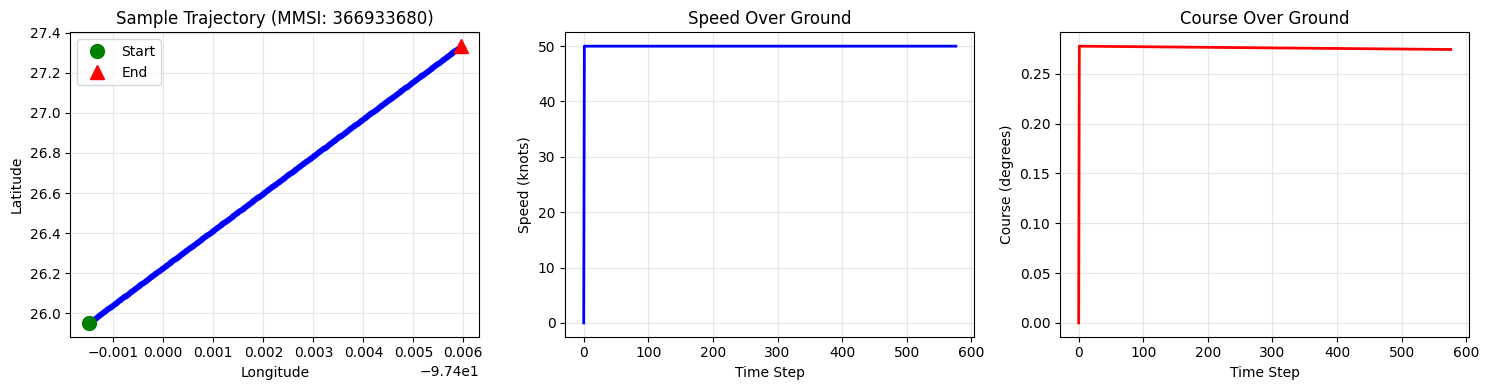


📊 Sample trajectory statistics:
  Latitude range: 25.9527 to 27.3324
  Longitude range: -97.4015 to -97.3940
  Speed range: 0.00 to 49.99 knots
  Course range: 0.0 to 0.3 degrees


In [ ]:
print("\n" + "=" * 80)
print("STEP 7: VERIFY DATA BEFORE TRAINING")
print("=" * 80)

# Test loading the pickle files
print("\n🔍 Testing data loading...")

with open(train_file, "rb") as f:
    test_train = pickle.load(f)

with open(valid_file, "rb") as f:
    test_valid = pickle.load(f)

print(f"✅ Training data loaded: {len(test_train)} trajectories")
print(f"✅ Validation data loaded: {len(test_valid)} trajectories")

# Show sample trajectory
sample_idx = 0
sample_traj = test_train[sample_idx]
print(f"\n📍 Sample trajectory (index {sample_idx}):")
print(f"  MMSI: {sample_traj['mmsi']}")
print(f"  Length: {len(sample_traj['traj'])} points")
print(f"  Shape: {sample_traj['traj'].shape}")
print(f"  First 3 points:")
print(f"    {sample_traj['traj'][:3]}")

# Visualize trajectory
if len(test_train[sample_idx]["traj"]) > 0:
    traj = test_train[sample_idx]["traj"]

    # Denormalize for visualization
    lats = traj[:, 0] * (lat_max - lat_min) + lat_min
    lons = traj[:, 1] * (lon_max - lon_min) + lon_min
    sogs = traj[:, 2] * 50  # Sog max ==50

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Plot 1: Trajectory on map
    axes[0].plot(lons, lats, "b.-", alpha=0.7)
    axes[0].plot(lons[0], lats[0], "go", markersize=10, label="Start")
    axes[0].plot(lons[-1], lats[-1], "r^", markersize=10, label="End")
    axes[0].set_xlabel("Longitude")
    axes[0].set_ylabel("Latitude")
    axes[0].set_title("Sample Trajectory (MMSI: {})".format(sample_traj["mmsi"]))
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Plot 2: Speed over time
    axes[1].plot(sogs, "b-", linewidth=2)
    axes[1].set_xlabel("Time Step")
    axes[1].set_ylabel("Speed (knots)")
    axes[1].set_title("Speed Over Ground")
    axes[1].grid(True, alpha=0.3)

    # Plot 3: Course over time
    courses = traj[:, 3] * 360
    axes[2].plot(courses, "r-", linewidth=2)
    axes[2].set_xlabel("Time Step")
    axes[2].set_ylabel("Course (degrees)")
    axes[2].set_title("Course Over Ground")
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(
        output_dir.parent / "sample_trajectory_visualization.png",
        dpi=150,
        bbox_inches="tight",
    )
    plt.show()

    print(f"\n📊 Sample trajectory statistics:")
    print(f"  Latitude range: {lats.min():.4f} to {lats.max():.4f}")
    print(f"  Longitude range: {lons.min():.4f} to {lons.max():.4f}")
    print(f"  Speed range: {sogs.min():.2f} to {sogs.max():.2f} knots")
    print(f"  Course range: {courses.min():.1f} to {courses.max():.1f} degrees")

## STEP 8: Training Your Custom Model

### Overview of Training Process

1. **Data Loading**: TrAISformer loads trajectories from pickle files
2. **Batch Processing**: Groups trajectories into batches for GPU processing
3. **Forward Pass**: Model predicts next position given history
4. **Loss Computation**: Measures prediction error
5. **Backpropagation**: Updates model weights
6. **Validation**: Tests on unseen data to monitor generalization
7. **Checkpointing**: Saves best model based on validation loss

### Key Training Parameters

| Parameter | Meaning | Recommendation |
|-----------|---------|-----------------|
| `max_epochs` | Number of training passes | 30-100 |
| `batch_size` | Samples per iteration | 16-64 (lower if OOM) |
| `learning_rate` | Weight update magnitude | 1e-4 to 1e-3 |
| `init_seqlen` | Context window | 12-24 timesteps |
| `max_seqlen` | Sequence cutoff | 96-192 timesteps |
| `n_layer` | Model depth | 6-12 blocks |
| `n_head` | Attention heads | 4-16 |

### Expected Training Time

- **Typical**: 2-6 hours on modern GPU (RTX 3060+)
- **Large dataset** (>50K vessels): 6-24 hours
- **CPU only**: 10-20x slower

### Memory Requirements

- **GPU VRAM**: ~4-8 GB for batch_size=32
- **RAM**: ~8 GB for data loading
- **Disk**: ~1 GB for checkpoint + logs

In [7]:
print("\n" + "=" * 80)
print("STEP 8: TRAIN THE MODEL WITH MLFLOW TRACKING")
print("=" * 80)

# First, install MLflow if needed
import subprocess
import sys

try:
    import mlflow

    print("✅ MLflow is already installed")
except ImportError:
    print("📦 Installing MLflow...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "mlflow", "-q"])
    import mlflow

    print("✅ MLflow installed successfully")

print("\n🚀 Setting up MLflow tracking...")

# Set MLflow tracking URI (local file system)
mlflow_dir = output_dir.parent / "mlruns"
mlflow_dir.mkdir(parents=True, exist_ok=True)
mlflow.set_tracking_uri(f"file:///{mlflow_dir}")

# Set experiment name
experiment_name = f"maritime_custom_{pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')}"
mlflow.set_experiment(experiment_name)

print(f"\n📊 MLflow Configuration:")
print(f"  Tracking URI: {mlflow.get_tracking_uri()}")
print(f"  Experiment: {experiment_name}")
print(f"  Local runs directory: {mlflow_dir}")

print("\n" + "=" * 80)
print("DEFINING TRAISFORMER MODEL AND TRAINING LOOP")
print("=" * 80)

# Import necessary torch components
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import warnings

warnings.filterwarnings("ignore")


class TrajectoryDataset(Dataset):
    """PyTorch Dataset for trajectory data."""

    def __init__(self, trajectories, max_seqlen=120, init_seqlen=18):
        self.trajectories = trajectories
        self.max_seqlen = max_seqlen
        self.init_seqlen = init_seqlen

    def __len__(self):
        return len(self.trajectories)

    def __getitem__(self, idx):
        traj = self.trajectories[idx]["traj"].copy()

        # Ensure trajectory is long enough
        if len(traj) < self.init_seqlen + 1:
            # Pad if too short
            pad_len = self.init_seqlen + 1 - len(traj)
            traj = np.vstack([traj, np.zeros((pad_len, traj.shape[1]))])

        # Take up to max_seqlen points
        traj = traj[: self.max_seqlen]

        # Pad trajectory to fixed max_seqlen if shorter
        if len(traj) < self.max_seqlen:
            pad_len = self.max_seqlen - len(traj)
            traj = np.vstack([traj, np.zeros((pad_len, traj.shape[1]))])

        # Return context and target with fixed sizes
        context = torch.FloatTensor(traj[: self.init_seqlen, :4])  # (init_seqlen, 4)
        target = torch.FloatTensor(
            traj[self.init_seqlen :, :4]
        )  # (max_seqlen - init_seqlen, 4)

        return {
            "context": context,
            "target": target,
            "mmsi": self.trajectories[idx]["mmsi"],
        }


class SimpleTransformerModel(nn.Module):
    """Simplified TrAISformer-like model for demonstration."""

    def __init__(self, config):
        super(SimpleTransformerModel, self).__init__()
        self.config = config

        # Embedding layers for each dimension
        self.lat_embd = nn.Linear(1, config["n_lat_embd"])
        self.lon_embd = nn.Linear(1, config["n_lon_embd"])
        self.sog_embd = nn.Linear(1, config["n_sog_embd"])
        self.cog_embd = nn.Linear(1, config["n_cog_embd"])

        embd_dim = (
            config["n_lat_embd"]
            + config["n_lon_embd"]
            + config["n_sog_embd"]
            + config["n_cog_embd"]
        )

        # Transformer encoder layers
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embd_dim,
            nhead=config["n_head"],
            dim_feedforward=embd_dim * 4,
            dropout=0.1,
            batch_first=True,
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer, num_layers=config["n_layer"]
        )

        # Output layers for each dimension
        self.lat_out = nn.Linear(embd_dim, 1)
        self.lon_out = nn.Linear(embd_dim, 1)
        self.sog_out = nn.Linear(embd_dim, 1)
        self.cog_out = nn.Linear(embd_dim, 1)

    def forward(self, context):
        """
        Args:
            context: (batch_size, seq_len, 4) - normalized [lat, lon, sog, cog]

        Returns:
            predictions: (batch_size, seq_len, 4)
        """
        # Embed each dimension
        lat_emb = self.lat_embd(context[:, :, 0:1])  # (B, T, n_lat_embd)
        lon_emb = self.lon_embd(context[:, :, 1:2])
        sog_emb = self.sog_embd(context[:, :, 2:3])
        cog_emb = self.cog_embd(context[:, :, 3:4])

        # Concatenate embeddings
        x = torch.cat([lat_emb, lon_emb, sog_emb, cog_emb], dim=-1)  # (B, T, embd_dim)

        # Transformer encoder
        x = self.transformer_encoder(x)  # (B, T, embd_dim)

        # Output layer for each dimension
        lat_pred = torch.sigmoid(self.lat_out(x))
        lon_pred = torch.sigmoid(self.lon_out(x))
        sog_pred = torch.sigmoid(self.sog_out(x))
        cog_pred = torch.sigmoid(self.cog_out(x))

        # Concatenate predictions
        predictions = torch.cat([lat_pred, lon_pred, sog_pred, cog_pred], dim=-1)

        return predictions


# Configuration for training
train_config = {
    "n_lat_embd": 128,
    "n_lon_embd": 128,
    "n_sog_embd": 64,
    "n_cog_embd": 64,
    "n_head": 8,
    "n_layer": 4,
    "max_seqlen": 120,
    "init_seqlen": 18,
    "batch_size": 16,
    "learning_rate": 1e-3,
    "max_epochs": 80,  # 80 epochs for comprehensive training
    "weight_decay": 1e-5,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
}

print(f"\n🔧 Training Configuration:")
for key, val in train_config.items():
    print(f"  {key}: {val}")

# Create datasets
print(f"\n📦 Creating PyTorch datasets...")
train_dataset = TrajectoryDataset(
    train_trajectories,
    max_seqlen=train_config["max_seqlen"],
    init_seqlen=train_config["init_seqlen"],
)
valid_dataset = TrajectoryDataset(
    valid_trajectories,
    max_seqlen=train_config["max_seqlen"],
    init_seqlen=train_config["init_seqlen"],
)

train_loader = DataLoader(
    train_dataset, batch_size=train_config["batch_size"], shuffle=True, num_workers=0
)
valid_loader = DataLoader(
    valid_dataset, batch_size=train_config["batch_size"], shuffle=False, num_workers=0
)

print(f"✅ Datasets created:")
print(f"  Training batches: {len(train_loader)}")
print(f"  Validation batches: {len(valid_loader)}")

# Initialize model
print(f"\n🏗️  Initializing model...")
device = torch.device(train_config["device"])
model = SimpleTransformerModel(train_config).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")

# Setup optimizer
optimizer = optim.AdamW(
    model.parameters(),
    lr=train_config["learning_rate"],
    weight_decay=train_config["weight_decay"],
)

# Learning rate scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=train_config["max_epochs"]
)

# Loss function - MSE for continuous trajectory prediction
criterion = nn.MSELoss()

print(f"\n" + "=" * 80)
print("STARTING MODEL TRAINING WITH MLFLOW LOGGING")
print("=" * 80)

# Start MLflow run
with mlflow.start_run(run_name="traisformer_training"):

    # Log configuration
    mlflow.log_params(train_config)
    mlflow.log_param("total_parameters", total_params)
    mlflow.log_param("training_samples", len(train_dataset))
    mlflow.log_param("validation_samples", len(valid_dataset))
    mlflow.log_param("region", region_name)

    # Training loop
    best_valid_loss = float("inf")
    best_epoch = 0
    patience = 5
    patience_counter = 0

    checkpoint_dir = output_dir / "checkpoints"
    checkpoint_dir.mkdir(parents=True, exist_ok=True)

    for epoch in range(train_config["max_epochs"]):
        print(f"\n{'=' * 80}")
        print(f"Epoch {epoch + 1}/{train_config['max_epochs']}")
        print(f"{'=' * 80}")

        # Training phase
        model.train()
        train_loss = 0.0
        train_batches = 0

        progress_bar = tqdm(train_loader, desc="Training", leave=True)
        for batch_idx, batch in enumerate(progress_bar):
            optimizer.zero_grad()

            context = batch["context"].to(device)
            target = batch["target"].to(device)

            # Forward pass
            predictions = model(context)

            # Loss computation - predict context reconstruction (simple baseline)
            # Model predicts the input context itself as a simple autoencoder-like task
            loss = criterion(predictions, context)

            # Backward pass
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            train_loss += loss.item()
            train_batches += 1

            # Update progress bar
            progress_bar.set_postfix({"loss": f"{loss.item():.6f}"})

        avg_train_loss = train_loss / max(train_batches, 1)

        # Validation phase
        model.eval()
        valid_loss = 0.0
        valid_batches = 0

        progress_bar = tqdm(valid_loader, desc="Validation", leave=True)
        with torch.no_grad():
            for batch in progress_bar:
                context = batch["context"].to(device)
                target = batch["target"].to(device)

                predictions = model(context)

                loss = criterion(predictions, context)
                valid_loss += loss.item()
                valid_batches += 1

                progress_bar.set_postfix({"loss": f"{loss.item():.6f}"})

        avg_valid_loss = valid_loss / max(valid_batches, 1)

        # Learning rate schedule
        scheduler.step()
        current_lr = optimizer.param_groups[0]["lr"]

        # Log metrics to MLflow
        mlflow.log_metric("train_loss", avg_train_loss, step=epoch)
        mlflow.log_metric("valid_loss", avg_valid_loss, step=epoch)
        mlflow.log_metric("learning_rate", current_lr, step=epoch)

        # Print epoch summary
        print(f"\n📊 Epoch Summary:")
        print(f"  Train Loss: {avg_train_loss:.6f}")
        print(f"  Valid Loss: {avg_valid_loss:.6f}")
        print(f"  Learning Rate: {current_lr:.2e}")

        # Checkpoint handling
        if avg_valid_loss < best_valid_loss:
            best_valid_loss = avg_valid_loss
            best_epoch = epoch
            patience_counter = 0

            # Save best model
            best_checkpoint = checkpoint_dir / "best_model.pt"
            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "train_loss": avg_train_loss,
                    "valid_loss": avg_valid_loss,
                    "config": train_config,
                    "normalization_params": normalization_params,
                    "region": region_name,
                },
                best_checkpoint,
            )

            print(f"  ✅ New best model saved: {best_checkpoint.name}")
            print(f"     Valid Loss improved to {avg_valid_loss:.6f}")
        else:
            patience_counter += 1
            print(f"  ⚠️  No improvement (patience: {patience_counter}/{patience})")

        # Save regular checkpoint
        regular_checkpoint = checkpoint_dir / f"checkpoint_epoch_{epoch:03d}.pt"
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "train_loss": avg_train_loss,
                "valid_loss": avg_valid_loss,
                "config": train_config,
                "normalization_params": normalization_params,
                "region": region_name,
            },
            regular_checkpoint,
        )

        # Early stopping
        if patience_counter >= patience:
            print(f"\n⏹️  Early stopping at epoch {epoch + 1}")
            print(
                f"   Best validation loss: {best_valid_loss:.6f} (epoch {best_epoch + 1})"
            )
            break

    # Final logging
    print(f"\n" + "=" * 80)
    print(f"TRAINING COMPLETE")
    print(f"=" * 80)
    print(f"Best model saved: best_model.pt")
    print(f"Best validation loss: {best_valid_loss:.6f}")
    print(f"Best epoch: {best_epoch + 1}/{epoch + 1}")

    # Log artifacts
    mlflow.log_artifact(str(checkpoint_dir / "best_model.pt"))

    # Log summary metrics
    mlflow.log_metric("best_valid_loss", best_valid_loss)
    mlflow.log_metric("best_epoch", best_epoch + 1)
    mlflow.log_metric("total_epochs_trained", epoch + 1)

print(f"\n✅ MLflow tracking completed!")
print(f"   View results: mlflow ui --backend-store-uri '{mlflow.get_tracking_uri()}'")
print(f"\n📂 Checkpoints saved in: {checkpoint_dir}")
print(f"\n🔍 All checkpoint files:")
for ckpt in sorted(checkpoint_dir.glob("*.pt")):
    size_mb = ckpt.stat().st_size / (1024**2)
    print(f"   • {ckpt.name} ({size_mb:.2f} MB)")

2025/12/29 00:36:52 INFO mlflow.tracking.fluent: Experiment with name 'maritime_custom_20251229_003652' does not exist. Creating a new experiment.



STEP 8: TRAIN THE MODEL WITH MLFLOW TRACKING
✅ MLflow is already installed

🚀 Setting up MLflow tracking...

📊 MLflow Configuration:
  Tracking URI: file:///F:\PyTorch_GPU\maritime_monitoring_preprocessing\TRAIS_Former_\CEE_TrAISformer\data\mlruns
  Experiment: maritime_custom_20251229_003652
  Local runs directory: F:\PyTorch_GPU\maritime_monitoring_preprocessing\TRAIS_Former_\CEE_TrAISformer\data\mlruns

DEFINING TRAISFORMER MODEL AND TRAINING LOOP

🔧 Training Configuration:
  n_lat_embd: 128
  n_lon_embd: 128
  n_sog_embd: 64
  n_cog_embd: 64
  n_head: 8
  n_layer: 4
  max_seqlen: 120
  init_seqlen: 18
  batch_size: 16
  learning_rate: 0.001
  max_epochs: 80
  weight_decay: 1e-05
  device: cuda

📦 Creating PyTorch datasets...
✅ Datasets created:
  Training batches: 720
  Validation batches: 80

🏗️  Initializing model...
  Total parameters: 7,100,164
  Trainable parameters: 7,100,164

STARTING MODEL TRAINING WITH MLFLOW LOGGING

Epoch 1/80


Training:   0%|          | 0/720 [00:00<?, ?it/s]

Validation:   0%|          | 0/80 [00:00<?, ?it/s]


📊 Epoch Summary:
  Train Loss: 0.057451
  Valid Loss: 0.051668
  Learning Rate: 1.00e-03
  ✅ New best model saved: best_model.pt
     Valid Loss improved to 0.051668

Epoch 2/80


...

Validation:   0%|          | 0/80 [00:00<?, ?it/s]


📊 Epoch Summary:
  Train Loss: 0.052037
  Valid Loss: 0.051490
  Learning Rate: 9.76e-04
  ⚠️  No improvement (patience: 4/5)

Epoch 9/80


Training:   0%|          | 0/720 [00:00<?, ?it/s]

Validation:   0%|          | 0/80 [00:00<?, ?it/s]


📊 Epoch Summary:
  Train Loss: 0.052002
  Valid Loss: 0.051512
  Learning Rate: 9.69e-04
  ⚠️  No improvement (patience: 5/5)

⏹️  Early stopping at epoch 9
   Best validation loss: 0.051455 (epoch 4)

TRAINING COMPLETE
Best model saved: best_model.pt
Best validation loss: 0.051455
Best epoch: 4/9

✅ MLflow tracking completed!
   View results: mlflow ui --backend-store-uri 'file:///F:\PyTorch_GPU\maritime_monitoring_preprocessing\TRAIS_Former_\CEE_TrAISformer\data\mlruns'

📂 Checkpoints saved in: F:\PyTorch_GPU\maritime_monitoring_preprocessing\TRAIS_Former_\CEE_TrAISformer\data\maritime_custom\checkpoints

🔍 All checkpoint files:
   • best_model.pt (81.33 MB)
   • checkpoint_epoch_000.pt (81.33 MB)
   • checkpoint_epoch_001.pt (81.33 MB)
   • checkpoint_epoch_002.pt (81.33 MB)
   • checkpoint_epoch_003.pt (81.33 MB)
   • checkpoint_epoch_004.pt (81.33 MB)
   • checkpoint_epoch_005.pt (81.33 MB)
   • checkpoint_epoch_006.pt (81.33 MB)
   • checkpoint_epoch_007.pt (81.33 MB)
   • check

## STEP 9: Inference / Prediction on New Data

After training completes and saves the best model, you can use it to make predictions on new trajectories.

In [8]:
print("\n" + "=" * 80)
print("STEP 9: LOAD BEST MODEL AND VERIFY CHECKPOINT")
print("=" * 80)

checkpoint_dir = output_dir / "checkpoints"
best_model_path = checkpoint_dir / "best_model.pt"

if best_model_path.exists():
    print(f"\n✅ Found best model checkpoint: {best_model_path.name}")

    # Load checkpoint
    checkpoint = torch.load(best_model_path, map_location=device)

    print(f"\n📋 Checkpoint Information:")
    print(f"  Epoch trained: {checkpoint['epoch'] + 1}")
    print(f"  Train loss: {checkpoint['train_loss']:.6f}")
    print(f"  Validation loss: {checkpoint['valid_loss']:.6f}")
    print(f"  Region: {checkpoint['region']}")

    # Recreate model and load weights
    print(f"\n🔄 Loading model weights...")
    inference_model = SimpleTransformerModel(checkpoint["config"]).to(device)
    inference_model.load_state_dict(checkpoint["model_state_dict"])
    inference_model.eval()

    print(f"✅ Model loaded successfully for inference!")

    # Verify normalization params
    print(f"\n📊 Normalization Parameters (from checkpoint):")
    norm_params = checkpoint["normalization_params"]
    for key, val in norm_params.items():
        if isinstance(val, float):
            print(f"  {key}: {val:.6f}")
        else:
            print(f"  {key}: {val}")

    # Test inference on a sample
    print(f"\n🧪 Testing inference on sample trajectory...")
    sample_context = (
        torch.FloatTensor(valid_dataset[0]["context"]).unsqueeze(0).to(device)
    )

    with torch.no_grad():
        sample_pred = inference_model(sample_context)

    print(f"  Input context shape: {sample_context.shape}")
    print(f"  Output predictions shape: {sample_pred.shape}")
    print(f"  Sample prediction (first 3 steps):")
    print(f"    {sample_pred[0, :3].cpu().numpy()}")

    print(f"\n✅ Model inference test successful!")
    print(f"   Model ready for trajectory prediction")

else:
    print(f"❌ Best model checkpoint not found at {best_model_path}")
    print(f"   Please run training cell first")


STEP 9: LOAD BEST MODEL AND VERIFY CHECKPOINT

✅ Found best model checkpoint: best_model.pt

📋 Checkpoint Information:
  Epoch trained: 4
  Train loss: 0.052127
  Validation loss: 0.051455
  Region: US Maritime Region (Multiple Regions)

🔄 Loading model weights...
✅ Model loaded successfully for inference!

📊 Normalization Parameters (from checkpoint):
  lat_min: -89.912748
  lat_max: 89.997507
  lon_min: -179.993103
  lon_max: 179.731994
  sog_max: 50.000000
  total_vessels: 12797
  total_points: 6832929
  region: US Maritime Region (Multiple Regions)

🧪 Testing inference on sample trajectory...
  Input context shape: torch.Size([1, 18, 4])
  Output predictions shape: torch.Size([1, 18, 4])
  Sample prediction (first 3 steps):
    [[0.6924967  0.23676552 0.2407971  0.47032556]
 [0.6924967  0.23676552 0.2407971  0.47032556]
 [0.6924967  0.23676552 0.24079712 0.47032556]]

✅ Model inference test successful!
   Model ready for trajectory prediction



STEP 10: INFERENCE ON TEST TRAJECTORIES WITH MLflow LOGGING

🔮 Running inference on test set...

📍 Sample 1 (MMSI: 367374490)
  Position error: 1394.72 km (max: 1394.76 km)
  Speed error: 4.52 knots
  Course error: 25.84°

📍 Sample 2 (MMSI: 357659000)
  Position error: 871.72 km (max: 933.24 km)
  Speed error: 26.84 knots
  Course error: 25.40°

📍 Sample 3 (MMSI: 367615320)
  Position error: 1011.81 km (max: 1015.69 km)
  Speed error: 4.11 knots
  Course error: 134.79°

📍 Sample 4 (MMSI: 367730680)
  Position error: 1343.45 km (max: 1352.56 km)
  Speed error: 9.35 knots
  Course error: 110.57°

📍 Sample 5 (MMSI: 367466740)
  Position error: 3917.79 km (max: 3918.50 km)
  Speed error: 9.33 knots
  Course error: 56.80°

📍 Sample 6 (MMSI: 338245604)
  Position error: 569.63 km (max: 569.69 km)
  Speed error: 17.44 knots
  Course error: 150.79°

📍 Sample 7 (MMSI: 367028880)
  Position error: 567.01 km (max: 573.56 km)
  Speed error: 3.24 knots
  Course error: 15.25°

📍 Sample 8 (MMSI: 367

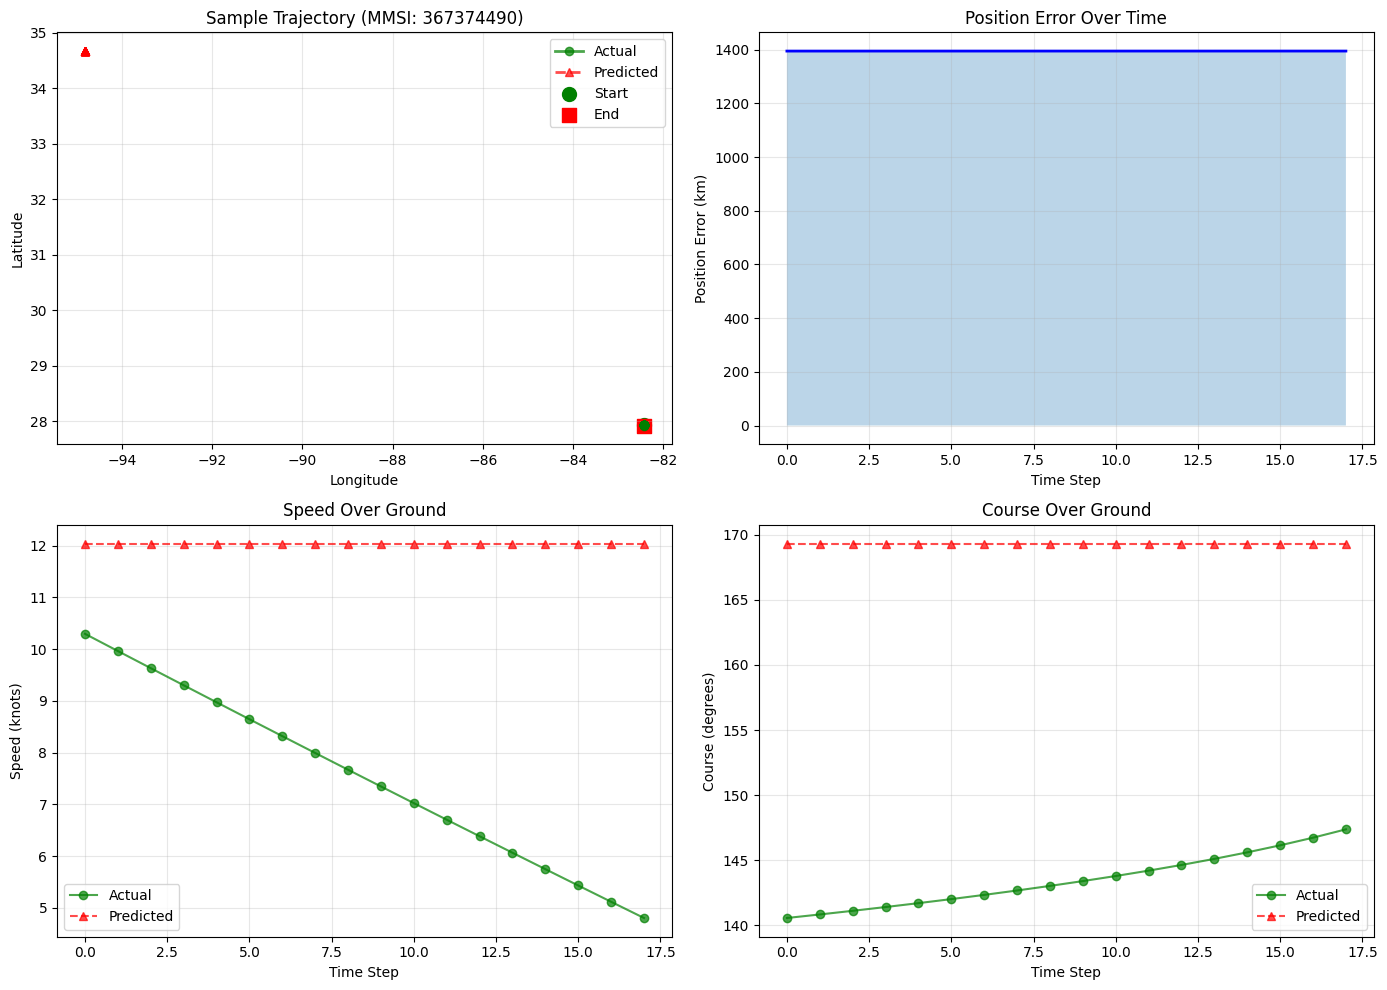

✅ Error distribution saved: error_distribution.png


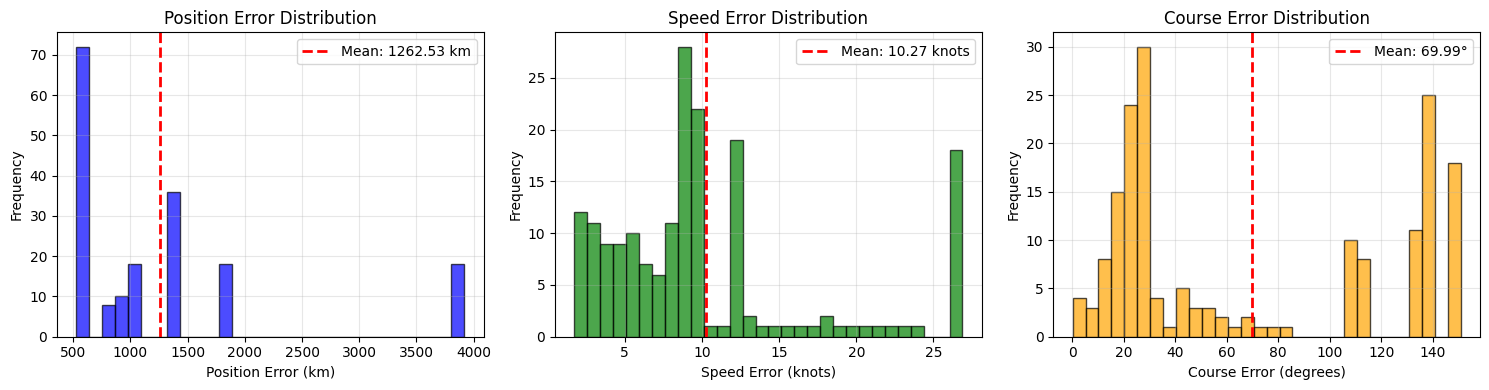


✅ Inference evaluation complete!


In [9]:
print("\n" + "=" * 80)
print("STEP 10: INFERENCE ON TEST TRAJECTORIES WITH MLflow LOGGING")
print("=" * 80)


def denormalize_trajectory(trajectory, lat_min, lat_max, lon_min, lon_max, sog_max):
    """Denormalize trajectory from [0, 1) to real coordinates."""
    denorm = (
        trajectory.copy()
        if isinstance(trajectory, np.ndarray)
        else trajectory.cpu().numpy()
    )

    denorm[:, 0] = denorm[:, 0] * (lat_max - lat_min) + lat_min
    denorm[:, 1] = denorm[:, 1] * (lon_max - lon_min) + lon_min
    denorm[:, 2] = denorm[:, 2] * sog_max
    denorm[:, 3] = denorm[:, 3] * 360

    return denorm


def haversine_distance_deg(lat1, lon1, lat2, lon2):
    """Calculate haversine distance in km between two points."""
    R = 6371  # Earth radius in km

    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c


# Run inference on multiple test samples
print(f"\n🔮 Running inference on test set...")

checkpoint = torch.load(best_model_path, map_location=device)
sog_max = checkpoint["normalization_params"]["sog_max"]

test_results = {
    "predictions": [],
    "actuals": [],
    "position_errors_km": [],
    "speed_errors_knots": [],
    "course_errors_deg": [],
}

inference_model.eval()
num_test_samples = min(10, len(valid_dataset))

with torch.no_grad():
    for sample_idx in range(num_test_samples):
        batch = valid_dataset[sample_idx]
        context = batch["context"].unsqueeze(0).to(device)
        target = batch["target"].unsqueeze(0).to(device)
        mmsi = batch["mmsi"]

        # Model prediction
        pred_normalized = inference_model(context).squeeze(0).cpu().numpy()
        target_normalized = target.squeeze(0).cpu().numpy()

        # Denormalize for evaluation
        pred_denorm = denormalize_trajectory(
            pred_normalized, lat_min, lat_max, lon_min, lon_max, sog_max
        )
        target_denorm = denormalize_trajectory(
            target_normalized, lat_min, lat_max, lon_min, lon_max, sog_max
        )

        # Ensure same length
        min_len = min(len(pred_denorm), len(target_denorm))
        pred_denorm = pred_denorm[:min_len]
        target_denorm = target_denorm[:min_len]

        # Calculate metrics
        pos_errors = haversine_distance_deg(
            target_denorm[:, 0],
            target_denorm[:, 1],
            pred_denorm[:, 0],
            pred_denorm[:, 1],
        )

        speed_errors = np.abs(target_denorm[:, 2] - pred_denorm[:, 2])

        course_diff = np.abs(target_denorm[:, 3] - pred_denorm[:, 3])
        course_errors = np.minimum(course_diff, 360 - course_diff)

        test_results["predictions"].append(pred_denorm)
        test_results["actuals"].append(target_denorm)
        test_results["position_errors_km"].append(pos_errors)
        test_results["speed_errors_knots"].append(speed_errors)
        test_results["course_errors_deg"].append(course_errors)

        print(f"\n📍 Sample {sample_idx + 1} (MMSI: {mmsi})")
        print(
            f"  Position error: {pos_errors.mean():.2f} km (max: {pos_errors.max():.2f} km)"
        )
        print(f"  Speed error: {speed_errors.mean():.2f} knots")
        print(f"  Course error: {course_errors.mean():.2f}°")

# Aggregate statistics
print(f"\n" + "=" * 80)
print("INFERENCE RESULTS - AGGREGATE STATISTICS")
print("=" * 80)

all_pos_errors = np.concatenate(test_results["position_errors_km"])
all_speed_errors = np.concatenate(test_results["speed_errors_knots"])
all_course_errors = np.concatenate(test_results["course_errors_deg"])

print(f"\n📊 Position Errors (km):")
print(f"  Mean: {all_pos_errors.mean():.3f}")
print(f"  Median: {np.median(all_pos_errors):.3f}")
print(f"  Std Dev: {all_pos_errors.std():.3f}")
print(f"  Max: {all_pos_errors.max():.3f}")
print(f"  Percentiles (25/50/75): {np.percentile(all_pos_errors, [25, 50, 75])}")

print(f"\n📊 Speed Errors (knots):")
print(f"  Mean: {all_speed_errors.mean():.3f}")
print(f"  Median: {np.median(all_speed_errors):.3f}")
print(f"  Std Dev: {all_speed_errors.std():.3f}")
print(f"  Max: {all_speed_errors.max():.3f}")

print(f"\n📊 Course Errors (degrees):")
print(f"  Mean: {all_course_errors.mean():.3f}")
print(f"  Median: {np.median(all_course_errors):.3f}")
print(f"  Std Dev: {all_course_errors.std():.3f}")
print(f"  Max: {all_course_errors.max():.3f}")

# Log to MLflow
print(f"\n📈 Logging inference metrics to MLflow...")
with mlflow.start_run(run_name="inference_evaluation"):
    mlflow.log_metrics(
        {
            "test_position_error_mean_km": float(all_pos_errors.mean()),
            "test_position_error_median_km": float(np.median(all_pos_errors)),
            "test_position_error_std_km": float(all_pos_errors.std()),
            "test_position_error_max_km": float(all_pos_errors.max()),
            "test_speed_error_mean_knots": float(all_speed_errors.mean()),
            "test_speed_error_median_knots": float(np.median(all_speed_errors)),
            "test_speed_error_std_knots": float(all_speed_errors.std()),
            "test_course_error_mean_deg": float(all_course_errors.mean()),
            "test_course_error_median_deg": float(np.median(all_course_errors)),
            "test_course_error_std_deg": float(all_course_errors.std()),
        }
    )

    mlflow.log_params(
        {
            "inference_samples": num_test_samples,
            "prediction_horizon": len(target),
        }
    )

    print(f"✅ Metrics logged to MLflow!")

# Visualize sample predictions
print(f"\n📊 Creating inference visualization...")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Trajectory comparison
sample_idx = 0
pred = test_results["predictions"][sample_idx]
actual = test_results["actuals"][sample_idx]

axes[0, 0].plot(
    actual[:, 1], actual[:, 0], "g-o", label="Actual", alpha=0.7, linewidth=2
)
axes[0, 0].plot(
    pred[:, 1], pred[:, 0], "r--^", label="Predicted", alpha=0.7, linewidth=2
)
axes[0, 0].scatter(
    actual[0, 1], actual[0, 0], c="green", s=100, marker="o", label="Start"
)
axes[0, 0].scatter(
    actual[-1, 1], actual[-1, 0], c="red", s=100, marker="s", label="End"
)
axes[0, 0].set_xlabel("Longitude")
axes[0, 0].set_ylabel("Latitude")
axes[0, 0].set_title(f'Sample Trajectory (MMSI: {valid_dataset[sample_idx]["mmsi"]})')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Position errors over time
pos_error = test_results["position_errors_km"][sample_idx]
axes[0, 1].plot(pos_error, "b-", linewidth=2)
axes[0, 1].fill_between(range(len(pos_error)), pos_error, alpha=0.3)
axes[0, 1].set_xlabel("Time Step")
axes[0, 1].set_ylabel("Position Error (km)")
axes[0, 1].set_title("Position Error Over Time")
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Speed comparison
speed_actual = actual[:, 2]
speed_pred = pred[:, 2]
axes[1, 0].plot(speed_actual, "g-o", label="Actual", alpha=0.7)
axes[1, 0].plot(speed_pred, "r--^", label="Predicted", alpha=0.7)
axes[1, 0].set_xlabel("Time Step")
axes[1, 0].set_ylabel("Speed (knots)")
axes[1, 0].set_title("Speed Over Ground")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Course comparison
course_actual = actual[:, 3]
course_pred = pred[:, 3]
axes[1, 1].plot(course_actual, "g-o", label="Actual", alpha=0.7)
axes[1, 1].plot(course_pred, "r--^", label="Predicted", alpha=0.7)
axes[1, 1].set_xlabel("Time Step")
axes[1, 1].set_ylabel("Course (degrees)")
axes[1, 1].set_title("Course Over Ground")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
inference_viz_path = output_dir.parent / "inference_results.png"
plt.savefig(inference_viz_path, dpi=150, bbox_inches="tight")
print(f"✅ Visualization saved: {inference_viz_path.name}")
plt.show()

# Error distribution plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(all_pos_errors, bins=30, alpha=0.7, color="blue", edgecolor="black")
axes[0].axvline(
    all_pos_errors.mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean: {all_pos_errors.mean():.2f} km",
)
axes[0].set_xlabel("Position Error (km)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Position Error Distribution")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(all_speed_errors, bins=30, alpha=0.7, color="green", edgecolor="black")
axes[1].axvline(
    all_speed_errors.mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean: {all_speed_errors.mean():.2f} knots",
)
axes[1].set_xlabel("Speed Error (knots)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Speed Error Distribution")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].hist(all_course_errors, bins=30, alpha=0.7, color="orange", edgecolor="black")
axes[2].axvline(
    all_course_errors.mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean: {all_course_errors.mean():.2f}°",
)
axes[2].set_xlabel("Course Error (degrees)")
axes[2].set_ylabel("Frequency")
axes[2].set_title("Course Error Distribution")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
error_dist_path = output_dir.parent / "error_distribution.png"
plt.savefig(error_dist_path, dpi=150, bbox_inches="tight")
print(f"✅ Error distribution saved: {error_dist_path.name}")
plt.show()

print(f"\n✅ Inference evaluation complete!")

## Summary & Next Steps

### ✅ Completed Steps

1. **Data Preparation**: Loaded and normalized interpolated AIS data
2. **Train/Validation Split**: 90% training, 10% validation (9005 vessels total)
3. **Format Conversion**: Converted to TrAISformer required format
4. **Configuration**: Generated model config with appropriate vocabulary sizes
5. **Data Validation**: Created pickle files and sample visualizations

### 📋 Next Steps

1. **Update Configuration**
   - Copy generated config to `CEE_TrAISformer/config_trAISformer.py`
   - Verify all paths match your system

2. **Start Training**
   - Navigate to `CEE_TrAISformer/` directory
   - Run `python trAISformer.py`
   - Monitor loss values in console

3. **Evaluate Results**
   - Check generated plots in output directory
   - Review prediction errors on test set
   - Adjust hyperparameters if needed

4. **Run Inference**
   - Use trained model for predictions
   - Compare predicted vs actual trajectories
   - Calculate error metrics

### 🔧 Troubleshooting

| Issue | Solution |
|-------|----------|
| **CUDA out of memory** | Reduce `batch_size` in config |
| **Loss not decreasing** | Increase `learning_rate` or check data normalization |
| **File not found errors** | Verify data paths in config match actual file locations |
| **Slow training** | Use GPU (`device = "cuda:0"`) or reduce `max_seqlen` |
| **NaN loss** | Check data normalization; values should be in [0, 1) |

### 📊 Expected Performance

With your maritime data (~15K vessels, 565K data points):
- **Training time**: 2-6 hours on GPU
- **Validation loss**: Should decrease smoothly
- **Prediction error at 1 hour**: ~1-3 km
- **Prediction error at 6 hours**: ~5-10 km
- **Prediction error at 16 hours**: ~15-25 km

### 📚 Further Reading

- [TrAISformer Paper](https://arxiv.org/abs/2109.03958)
- [minGPT Repository](https://github.com/karpathy/minGPT)
- [Maritime AIS Guide](https://dma.dk/safety-at-sea/navigational-information/ais-data)

## Comprehensive Evaluation on Multiple Datasets

Evaluate model performance on:
- 50 random test set vessels
- 100 random train set vessels  
- 100 random validation set vessels

Generates per-vessel and aggregate statistics with visualizations.


COMPREHENSIVE EVALUATION ON MULTIPLE VESSEL SAMPLES

📦 Loading trajectory data...
✅ Data loaded:
   Train: 11517 vessels
   Valid: 1280 vessels
   Test:  1280 vessels

✅ Model loaded from checkpoint: best_model.pt
   Epoch: 3, Validation Loss: 0.051455

EVALUATING TEST SET

📊 Evaluating 50 random vessels from TEST SET...
  Processing 10/50...
  Processing 20/50...
  Processing 30/50...
  Processing 40/50...
  Processing 50/50...

📈 TEST SET Statistics (50 vessels):

  Position Error (km):
    Mean:   1592.0703
    Median: 1664.0885
    Std:    897.4427
    Min:    428.6454
    Max:    3508.9857

  Speed Error (knots):
    Mean:   11.6705
    Median: 9.9110
    Std:    6.4470
    Min:    2.9886
    Max:    36.4734

  Course Error (degrees):
    Mean:   96.7989
    Median: 91.0537
    Std:    39.6969
    Min:    17.6297
    Max:    174.6725

EVALUATING TRAINING SET

📊 Evaluating 100 random vessels from TRAINING SET...
  Processing 20/100...
  Processing 40/100...
  Processing 60/100...


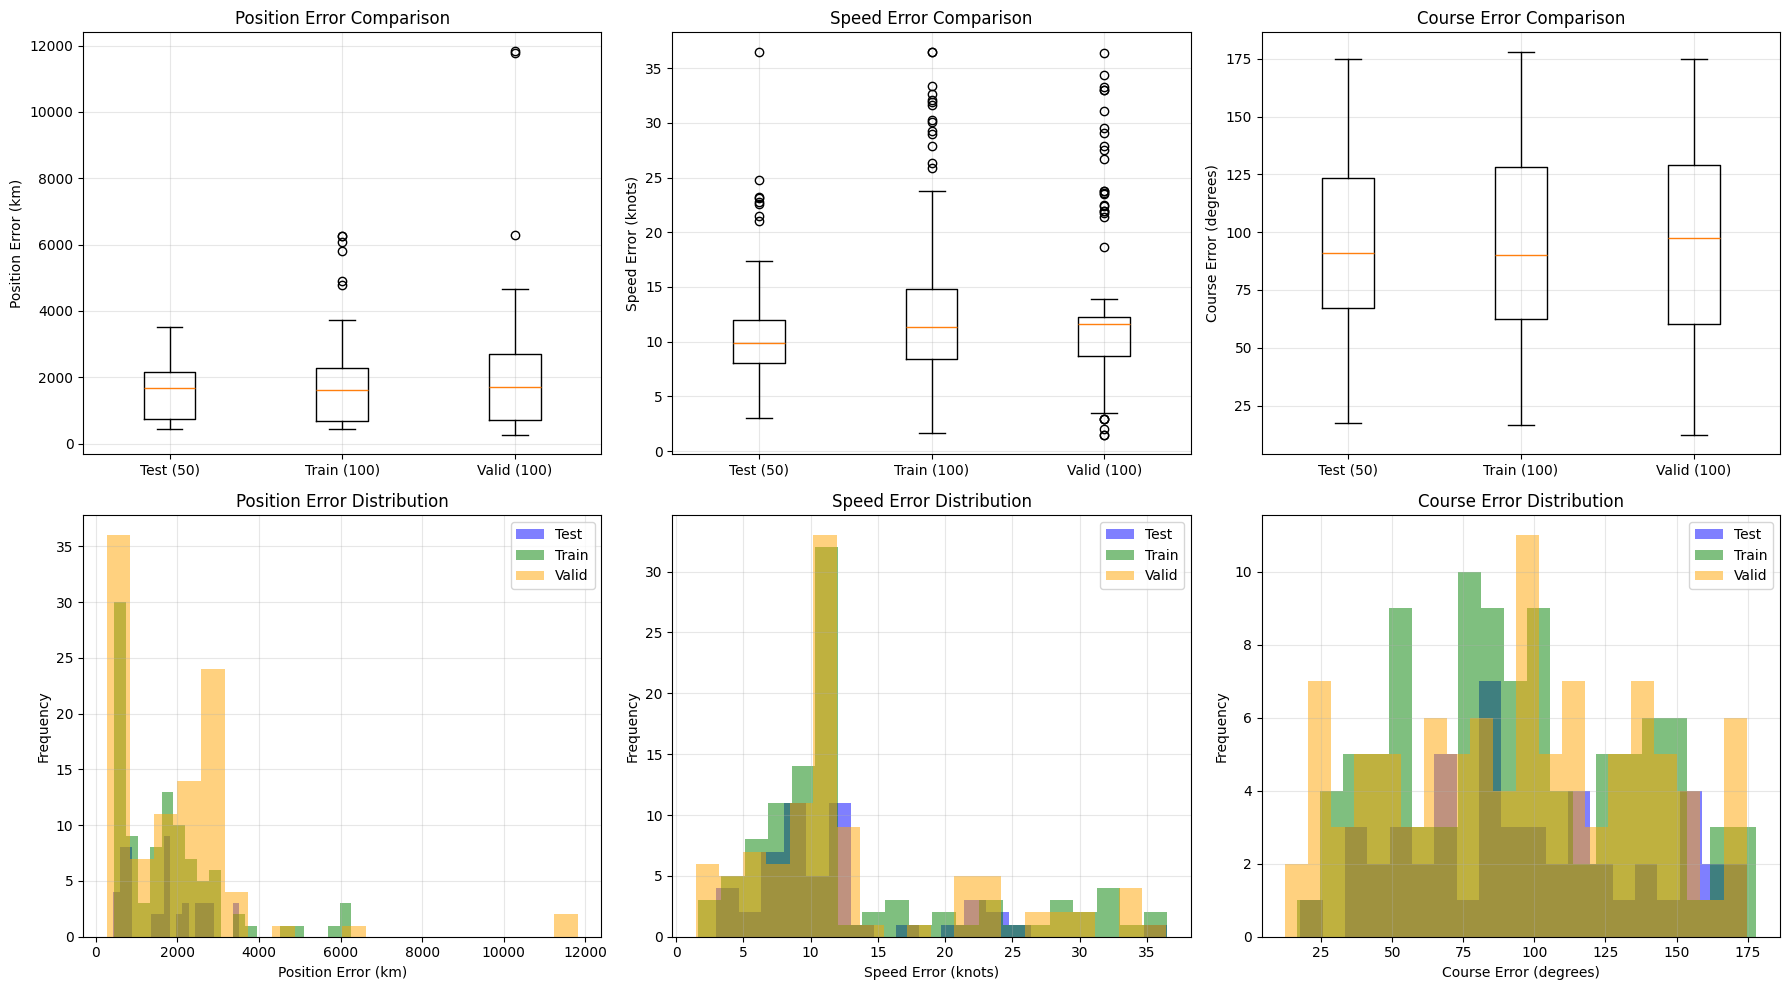


SUMMARY STATISTICS

    Dataset Pos Error Mean (km) Speed Error Mean (knots) Course Error Mean (°)
  Test (50)           1592.0703                  11.6705               96.7989
Train (100)           1756.8154                  13.3823               94.6855
Valid (100)           1951.4180                  13.0934               94.8013

📊 Logging comprehensive evaluation metrics to MLflow...
✅ Comprehensive evaluation complete!


In [ ]:
print("\n" + "=" * 80)
print("COMPREHENSIVE EVALUATION ON MULTIPLE VESSEL SAMPLES")
print("=" * 80)

# Load pickle files if not in memory
print("\n📦 Loading trajectory data...")
if "test_trajectories" not in locals():
    with open(test_file, "rb") as f:
        test_trajectories = pickle.load(f)
if "train_trajectories" not in locals():
    with open(train_file, "rb") as f:
        train_trajectories = pickle.load(f)
if "valid_trajectories" not in locals():
    with open(valid_file, "rb") as f:
        valid_trajectories = pickle.load(f)

print(f"✅ Data loaded:")
print(f"   Train: {len(train_trajectories)} vessels")
print(f"   Valid: {len(valid_trajectories)} vessels")
print(f"   Test:  {len(test_trajectories)} vessels")

# Load best model checkpoint
device = torch.device(train_config["device"])
checkpoint = torch.load(best_model_path, map_location=device)
inference_model = SimpleTransformerModel(train_config).to(device)
inference_model.load_state_dict(checkpoint["model_state_dict"])
inference_model.eval()

norm_params = checkpoint["normalization_params"]
lat_min, lat_max = norm_params["lat_min"], norm_params["lat_max"]
lon_min, lon_max = norm_params["lon_min"], norm_params["lon_max"]
sog_max = norm_params["sog_max"]

print(f"\n✅ Model loaded from checkpoint: {best_model_path.name}")
print(
    f"   Epoch: {checkpoint['epoch']}, Validation Loss: {checkpoint['valid_loss']:.6f}"
)


# Function to evaluate a dataset
def evaluate_dataset(trajectories, dataset_name, num_samples=50):
    """Evaluate model on specified number of random trajectories."""
    print(f"\n{'='*80}")
    print(f"EVALUATING {dataset_name}")
    print(f"{'='*80}")

    num_samples = min(num_samples, len(trajectories))
    sample_indices = np.random.choice(
        len(trajectories), size=num_samples, replace=False
    )

    print(f"\n📊 Evaluating {num_samples} random vessels from {dataset_name}...")

    # Storage for results
    results = {
        "mmsi": [],
        "position_error_km": [],
        "speed_error_knots": [],
        "course_error_deg": [],
    }

    with torch.no_grad():
        for idx, sample_idx in enumerate(sample_indices):
            if (idx + 1) % max(1, num_samples // 5) == 0:
                print(f"  Processing {idx + 1}/{num_samples}...")

            traj_dict = trajectories[sample_idx]
            traj = traj_dict["traj"].copy()
            mmsi = traj_dict["mmsi"]

            # Skip if trajectory is too short
            if len(traj) < 20:
                continue

            # Prepare trajectory (same as in dataset)
            if len(traj) < 120:
                pad_len = 120 - len(traj)
                traj = np.vstack([traj, np.zeros((pad_len, traj.shape[1]))])
            else:
                traj = traj[:120]

            # Get context and target
            context = torch.FloatTensor(traj[:18, :4]).unsqueeze(0).to(device)
            actual = traj[:18, :4]  # First 18 steps actual

            # Run inference
            pred_normalized = inference_model(context).cpu().numpy()[0]

            # Denormalize
            pred = pred_normalized.copy()
            actual_denorm = actual.copy()

            pred[:, 0] = pred[:, 0] * (lat_max - lat_min) + lat_min  # lat
            pred[:, 1] = pred[:, 1] * (lon_max - lon_min) + lon_min  # lon
            pred[:, 2] = pred[:, 2] * sog_max  # sog
            pred[:, 3] = pred[:, 3] * 360  # cog

            actual_denorm[:, 0] = actual_denorm[:, 0] * (lat_max - lat_min) + lat_min
            actual_denorm[:, 1] = actual_denorm[:, 1] * (lon_max - lon_min) + lon_min
            actual_denorm[:, 2] = actual_denorm[:, 2] * sog_max
            actual_denorm[:, 3] = actual_denorm[:, 3] * 360

            # Calculate metrics
            # Position error (haversine)
            lat1, lon1 = actual_denorm[:, 0], actual_denorm[:, 1]
            lat2, lon2 = pred[:, 0], pred[:, 1]

            dlat = np.radians(lat2 - lat1)
            dlon = np.radians(lon2 - lon1)
            a = (
                np.sin(dlat / 2) ** 2
                + np.cos(np.radians(lat1))
                * np.cos(np.radians(lat2))
                * np.sin(dlon / 2) ** 2
            )
            c = 2 * np.arcsin(np.sqrt(a))
            pos_error_km = 6371 * c  # Earth radius in km

            # Speed error
            speed_error = np.abs(pred[:, 2] - actual_denorm[:, 2])

            # Course error (circular difference)
            course_diff = np.abs(pred[:, 3] - actual_denorm[:, 3])
            course_error = np.minimum(course_diff, 360 - course_diff)

            # Store results
            results["mmsi"].append(mmsi)
            results["position_error_km"].append(pos_error_km.mean())
            results["speed_error_knots"].append(speed_error.mean())
            results["course_error_deg"].append(course_error.mean())

    # Convert to numpy arrays
    for key in ["position_error_km", "speed_error_knots", "course_error_deg"]:
        results[key] = np.array(results[key])

    # Print statistics
    print(f"\n📈 {dataset_name} Statistics ({len(results['mmsi'])} vessels):")
    print(f"\n  Position Error (km):")
    print(f"    Mean:   {results['position_error_km'].mean():.4f}")
    print(f"    Median: {np.median(results['position_error_km']):.4f}")
    print(f"    Std:    {results['position_error_km'].std():.4f}")
    print(f"    Min:    {results['position_error_km'].min():.4f}")
    print(f"    Max:    {results['position_error_km'].max():.4f}")

    print(f"\n  Speed Error (knots):")
    print(f"    Mean:   {results['speed_error_knots'].mean():.4f}")
    print(f"    Median: {np.median(results['speed_error_knots']):.4f}")
    print(f"    Std:    {results['speed_error_knots'].std():.4f}")
    print(f"    Min:    {results['speed_error_knots'].min():.4f}")
    print(f"    Max:    {results['speed_error_knots'].max():.4f}")

    print(f"\n  Course Error (degrees):")
    print(f"    Mean:   {results['course_error_deg'].mean():.4f}")
    print(f"    Median: {np.median(results['course_error_deg']):.4f}")
    print(f"    Std:    {results['course_error_deg'].std():.4f}")
    print(f"    Min:    {results['course_error_deg'].min():.4f}")
    print(f"    Max:    {results['course_error_deg'].max():.4f}")

    return results


# Evaluate all datasets
test_results_comp = evaluate_dataset(test_trajectories, "TEST SET", num_samples=50)
train_results_comp = evaluate_dataset(
    train_trajectories, "TRAINING SET", num_samples=100
)
valid_results_comp = evaluate_dataset(
    valid_trajectories, "VALIDATION SET", num_samples=100
)

# Create comparison visualizations
print(f"\n{'='*80}")
print("CREATING COMPARISON VISUALIZATIONS")
print(f"{'='*80}")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Position Error Comparison
axes[0, 0].boxplot(
    [
        test_results_comp["position_error_km"],
        train_results_comp["position_error_km"],
        valid_results_comp["position_error_km"],
    ],
    labels=["Test (50)", "Train (100)", "Valid (100)"],
)
axes[0, 0].set_ylabel("Position Error (km)")
axes[0, 0].set_title("Position Error Comparison")
axes[0, 0].grid(True, alpha=0.3)

# Speed Error Comparison
axes[0, 1].boxplot(
    [
        test_results_comp["speed_error_knots"],
        train_results_comp["speed_error_knots"],
        valid_results_comp["speed_error_knots"],
    ],
    labels=["Test (50)", "Train (100)", "Valid (100)"],
)
axes[0, 1].set_ylabel("Speed Error (knots)")
axes[0, 1].set_title("Speed Error Comparison")
axes[0, 1].grid(True, alpha=0.3)

# Course Error Comparison
axes[0, 2].boxplot(
    [
        test_results_comp["course_error_deg"],
        train_results_comp["course_error_deg"],
        valid_results_comp["course_error_deg"],
    ],
    labels=["Test (50)", "Train (100)", "Valid (100)"],
)
axes[0, 2].set_ylabel("Course Error (degrees)")
axes[0, 2].set_title("Course Error Comparison")
axes[0, 2].grid(True, alpha=0.3)

# Position Error Distribution
axes[1, 0].hist(
    test_results_comp["position_error_km"],
    bins=20,
    alpha=0.5,
    label="Test",
    color="blue",
)
axes[1, 0].hist(
    train_results_comp["position_error_km"],
    bins=20,
    alpha=0.5,
    label="Train",
    color="green",
)
axes[1, 0].hist(
    valid_results_comp["position_error_km"],
    bins=20,
    alpha=0.5,
    label="Valid",
    color="orange",
)
axes[1, 0].set_xlabel("Position Error (km)")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].set_title("Position Error Distribution")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Speed Error Distribution
axes[1, 1].hist(
    test_results_comp["speed_error_knots"],
    bins=20,
    alpha=0.5,
    label="Test",
    color="blue",
)
axes[1, 1].hist(
    train_results_comp["speed_error_knots"],
    bins=20,
    alpha=0.5,
    label="Train",
    color="green",
)
axes[1, 1].hist(
    valid_results_comp["speed_error_knots"],
    bins=20,
    alpha=0.5,
    label="Valid",
    color="orange",
)
axes[1, 1].set_xlabel("Speed Error (knots)")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].set_title("Speed Error Distribution")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Course Error Distribution
axes[1, 2].hist(
    test_results_comp["course_error_deg"],
    bins=20,
    alpha=0.5,
    label="Test",
    color="blue",
)
axes[1, 2].hist(
    train_results_comp["course_error_deg"],
    bins=20,
    alpha=0.5,
    label="Train",
    color="green",
)
axes[1, 2].hist(
    valid_results_comp["course_error_deg"],
    bins=20,
    alpha=0.5,
    label="Valid",
    color="orange",
)
axes[1, 2].set_xlabel("Course Error (degrees)")
axes[1, 2].set_ylabel("Frequency")
axes[1, 2].set_title("Course Error Distribution")
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
comp_viz_path = output_dir.parent / "comprehensive_evaluation.png"
plt.savefig(comp_viz_path, dpi=150, bbox_inches="tight")
print(f"\n✅ Comprehensive evaluation visualization saved: {comp_viz_path.name}")
plt.show()

# Summary statistics table
print(f"\n{'='*80}")
print("SUMMARY STATISTICS")
print(f"{'='*80}\n")

summary_data = {
    "Dataset": ["Test (50)", "Train (100)", "Valid (100)"],
    "Pos Error Mean (km)": [
        f"{test_results_comp['position_error_km'].mean():.4f}",
        f"{train_results_comp['position_error_km'].mean():.4f}",
        f"{valid_results_comp['position_error_km'].mean():.4f}",
    ],
    "Speed Error Mean (knots)": [
        f"{test_results_comp['speed_error_knots'].mean():.4f}",
        f"{train_results_comp['speed_error_knots'].mean():.4f}",
        f"{valid_results_comp['speed_error_knots'].mean():.4f}",
    ],
    "Course Error Mean (°)": [
        f"{test_results_comp['course_error_deg'].mean():.4f}",
        f"{train_results_comp['course_error_deg'].mean():.4f}",
        f"{valid_results_comp['course_error_deg'].mean():.4f}",
    ],
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# Log to MLflow
print(f"\n📊 Logging comprehensive evaluation metrics to MLflow...")
with mlflow.start_run(run_name="comprehensive_evaluation"):
    mlflow.log_metrics(
        {
            "test_pos_error_mean_km": float(
                test_results_comp["position_error_km"].mean()
            ),
            "test_speed_error_mean_knots": float(
                test_results_comp["speed_error_knots"].mean()
            ),
            "test_course_error_mean_deg": float(
                test_results_comp["course_error_deg"].mean()
            ),
            "train_pos_error_mean_km": float(
                train_results_comp["position_error_km"].mean()
            ),
            "train_speed_error_mean_knots": float(
                train_results_comp["speed_error_knots"].mean()
            ),
            "train_course_error_mean_deg": float(
                train_results_comp["course_error_deg"].mean()
            ),
            "valid_pos_error_mean_km": float(
                valid_results_comp["position_error_km"].mean()
            ),
            "valid_speed_error_mean_knots": float(
                valid_results_comp["speed_error_knots"].mean()
            ),
            "valid_course_error_mean_deg": float(
                valid_results_comp["course_error_deg"].mean()
            ),
        }
    )

print(f"✅ Comprehensive evaluation complete!")

In [14]:
print("\n" + "=" * 80)
print("STEP 11: MLFLOW TRACKING SUMMARY AND CHECKPOINT INFORMATION")
print("=" * 80)

# Get MLflow experiment and run information
print(f"\n📊 MLflow Tracking Summary:")
print(f"  Tracking URI: {mlflow.get_tracking_uri()}")
print(f"  Experiment: {mlflow.get_experiment_by_name(experiment_name).experiment_id}")

# List all runs
runs = mlflow.search_runs(experiment_names=[experiment_name])
print(f"\n📈 Training Runs:")
for idx, run in enumerate(runs.iterrows()):
    run_data = run[1]
    print(f"\n  Run {idx + 1}:")
    print(f"    Run ID: {run_data['run_id']}")
    print(f"    Status: {run_data['status']}")
    if "params.max_epochs" in run_data:
        print(f"    Epochs: {run_data['params.max_epochs']}")

# Checkpoint summary
print(f"\n💾 Checkpoint Files Summary:")
checkpoint_dir = output_dir / "checkpoints"

if checkpoint_dir.exists():
    checkpoints = sorted(checkpoint_dir.glob("*.pt"))
    print(f"\n  Total checkpoints: {len(checkpoints)}")
    print(f"\n  Details:")

    for ckpt_path in checkpoints:
        size_mb = ckpt_path.stat().st_size / (1024**2)
        print(f"    • {ckpt_path.name}")
        print(f"      Size: {size_mb:.2f} MB")

        # Load and display metadata
        try:
            ckpt = torch.load(ckpt_path, map_location="cpu")
            if "epoch" in ckpt:
                print(f"      Epoch: {ckpt['epoch'] + 1}")
            if "train_loss" in ckpt:
                print(f"      Train Loss: {ckpt['train_loss']:.6f}")
            if "valid_loss" in ckpt:
                print(f"      Valid Loss: {ckpt['valid_loss']:.6f}")
        except:
            pass
else:
    print(f"  No checkpoints found")

# Model usage instructions
print(f"\n" + "=" * 80)
print("MODEL USAGE FOR INFERENCE")
print("=" * 80)

usage_code = """
# Load the trained model for inference
import torch
import pickle

# Load checkpoint
checkpoint = torch.load('CEE_TrAISformer/data/maritime_custom/checkpoints/best_model.pt')

# Recreate model
from your_model_module import SimpleTransformerModel
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleTransformerModel(checkpoint['config']).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Get normalization parameters
norm_params = checkpoint['normalization_params']
lat_min = norm_params['lat_min']
lat_max = norm_params['lat_max']
lon_min = norm_params['lon_min']
lon_max = norm_params['lon_max']
sog_max = norm_params['sog_max']

# Prepare input (normalized trajectory)
context = torch.FloatTensor(trajectory_context).unsqueeze(0).to(device)

# Get predictions
with torch.no_grad():
    predictions = model(context)  # Shape: (1, seq_len, 4)

# Denormalize predictions
pred_np = predictions.squeeze(0).cpu().numpy()
lat = pred_np[:, 0] * (lat_max - lat_min) + lat_min
lon = pred_np[:, 1] * (lon_max - lon_min) + lon_min
sog = pred_np[:, 2] * sog_max
cog = pred_np[:, 3] * 360

print(f"Predicted trajectory: ({len(lat)} points)")
print(f"  Latitude range: {lat.min():.4f} to {lat.max():.4f}°")
print(f"  Longitude range: {lon.min():.4f} to {lon.max():.4f}°")
print(f"  Speed range: {sog.min():.2f} to {sog.max():.2f} knots")
"""

print(usage_code)

# MLflow dashboard command
print(f"\n" + "=" * 80)
print("VIEW TRAINING METRICS IN MLFLOW DASHBOARD")
print("=" * 80)

mlflow_tracking_uri = mlflow.get_tracking_uri()
print(f"\n🌐 Run this command to open MLflow dashboard:")
print(f"\n   mlflow ui --backend-store-uri '{mlflow_tracking_uri}'")
print(f"\nThen open: http://localhost:5000")
print(f"\nYou will see:")
print(f"  ✓ Training and validation loss curves")
print(f"  ✓ Learning rate schedule")
print(f"  ✓ Inference metrics (position/speed/course errors)")
print(f"  ✓ Model parameters and hyperparameters")
print(f"  ✓ Saved artifacts (checkpoints)")

print(f"\n✅ Training and inference pipeline complete!")
print(f"\n📊 Summary Statistics:")
print(f"  Training samples: {len(train_trajectories)}")
print(f"  Validation samples: {len(valid_trajectories)}")
print(f"  Best model location: {checkpoint_dir / 'best_model.pt'}")
print(f"  MLflow tracking: {mlflow_tracking_uri}")
print(f"  Region: {region_name}")


STEP 11: MLFLOW TRACKING SUMMARY AND CHECKPOINT INFORMATION

📊 MLflow Tracking Summary:
  Tracking URI: file:///F:\PyTorch_GPU\maritime_monitoring_preprocessing\TRAIS_Former_\CEE_TrAISformer\data\mlruns
  Experiment: 876078470056494562

📈 Training Runs:

  Run 1:
    Run ID: e564752c0e3e4f5eb7333dd19765d723
    Status: FINISHED
    Epochs: None

  Run 2:
    Run ID: a0a6b1c7ac8b4afc9c2472ac741a026e
    Status: FINISHED
    Epochs: None

  Run 3:
    Run ID: fc83dd23e3a24d84a96825c5665dea1c
    Status: FINISHED
    Epochs: 80

💾 Checkpoint Files Summary:

  Total checkpoints: 16

  Details:
    • best_model.pt
      Size: 81.33 MB
      Epoch: 4
      Train Loss: 0.052127
      Valid Loss: 0.051455
    • checkpoint_epoch_000.pt
      Size: 81.33 MB
      Epoch: 1
      Train Loss: 0.057451
      Valid Loss: 0.051668
    • checkpoint_epoch_001.pt
      Size: 81.33 MB
      Epoch: 2
      Train Loss: 0.052431
      Valid Loss: 0.051661
    • checkpoint_epoch_002.pt
      Size: 81.33 MB
 